# Customer Lifetime Value (LTV) Prediction Model

## Project Overview

### Objective:
The objective of this project is to predict Customer Lifetime Value (LTV) by analyzing customer purchasing behavior and transaction history. The project uses data preprocessing, exploratory data analysis, RFM analysis, and machine learning techniques to identify high-value customers and support better business decisions.

# 1. Importing Required Libraries

### Objective:
Importing necessary Python libraries for data manipulation, visualization, and machine learning tasks.

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display all columns
pd.set_option("display.max_columns", None)

### Observation:
All required Python libraries were successfully imported and prepared for data analysis, visualization, and model development.

# 2. Loading the Dataset

### Objective:
Loading the Online Retail dataset into the Python environment for customer transaction analysis.

In [2]:
# Loading dataset

df = pd.read_csv("../Dataset/online_retail.csv")

In [3]:
# Display first 5 records

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Observation:
The dataset was successfully loaded and contains customer transaction details including invoices, products, quantity, prices, customer IDs, and countries.

# 3. Data Understanding

### Objective:
Understanding the dataset structure, dimensions, data types, and identifying data quality issues before preprocessing.

In [4]:
# Checking number of rows and columns

df.shape

(541909, 8)

### Observation:
The original dataset contains 541,909 transaction records and 8 columns.

In [5]:
# Checking dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Observation:
The dataset contains different data types. CustomerID and Description columns have missing values, and InvoiceDate needs to be converted into datetime format.

In [6]:
# Statistical summary of numerical columns

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Observation:
The numerical features show variations in quantity and unit price, indicating the need for further validation and data cleaning.

In [7]:
# Checking missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# 4. Data Cleaning and Preprocessing

## Objective:
The objective of this phase is to improve data quality by handling missing values, duplicate records, invalid transactions, and incorrect data types.

In [8]:
# Creating a copy of original dataset

df_clean = df.copy()

### Observation:
A copy of the original dataset was created to preserve the raw data and perform cleaning operations safely.

### Removing Missing Customer IDs

Customer ID is required to identify unique customers and calculate Customer Lifetime Value (LTV). Therefore, records with missing Customer IDs are removed.

In [9]:
# Removing rows with missing CustomerID

df_clean = df_clean.dropna(subset=['CustomerID'])

In [10]:
# Checking dataset dimensions after removing missing values

df_clean.shape

(406829, 8)

### Observation:
After removing records with missing Customer IDs, the dataset contains 406,829 rows and 8 columns.

In [11]:
# Checking remaining missing values

df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Observation:
All missing values were successfully handled, and the dataset does not contain any null values.

### Identifying Duplicate Records

Duplicate transactions can affect revenue calculations and customer analysis. Therefore, duplicate records are identified before removal.

In [12]:
# Checking duplicate records

df_clean.duplicated().sum()

np.int64(5225)

### Removing Duplicate Records

Duplicate records can create incorrect insights by counting the same transaction multiple times. Therefore, duplicate records are removed to maintain data accuracy.

In [13]:
# Removing duplicate records

df_clean = df_clean.drop_duplicates()

In [14]:
# Checking dataset shape after removing duplicates

df_clean.shape

(401604, 8)

### Observation:
A total of 5,225 duplicate records were removed from the dataset, resulting in a cleaner dataset for further analysis.

### Identifying Invalid Transactions

Negative quantities represent returned products, and zero or negative prices indicate invalid transactions. These records need to be handled to ensure accurate revenue and customer analysis.

In [15]:
# Checking records with negative quantity

(df_clean['Quantity'] < 0).sum()

np.int64(8872)

In [16]:
# Checking records with zero or negative unit price

(df_clean['UnitPrice'] <= 0).sum()

np.int64(40)

### Removing Invalid Transactions

Transactions with negative quantities represent product returns, and transactions with zero or negative prices do not contribute to actual revenue. Therefore, these invalid records are removed to ensure accurate customer lifetime value analysis.

In [17]:
# Removing records with negative quantity

df_clean = df_clean[df_clean['Quantity'] > 0]

# Removing records with zero or negative unit price

df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [18]:
# Checking dataset dimensions after removing invalid transactions

df_clean.shape

(392692, 8)

### Observation:
Invalid transactions were removed from the dataset. The remaining records represent valid customer purchases and will be used for accurate revenue analysis and LTV prediction.

### Observation:
After removing invalid transactions such as returned products (negative quantity) and records with zero or negative prices, the dataset contains 392,692 valid transaction records and 8 columns. This cleaned data is now suitable for revenue analysis, customer segmentation, and Customer Lifetime Value prediction.

### Converting Data Types

Correct data types are essential for accurate time-based analysis and customer-level calculations. Therefore, InvoiceDate and CustomerID are converted into appropriate formats.

In [19]:
# Converting InvoiceDate from object to datetime format

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [20]:
# Converting CustomerID from float to integer format

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [21]:
# Checking updated data types

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB


### Observation:
InvoiceDate was converted into datetime format, allowing time-based analysis such as recency and sales trends. CustomerID was converted into integer format to ensure accurate customer identification and segmentation.

### Data Cleaning Summary

The dataset was successfully cleaned by handling missing customer IDs, removing duplicate records, eliminating invalid transactions, and converting columns into appropriate data types. The final dataset contains 392,692 valid transactions and is ready for feature engineering, exploratory data analysis, and customer lifetime value prediction.

# 5. Feature Engineering

## Objective:
Creating new features from existing data to improve customer behavior analysis, revenue calculation, and machine learning model performance.

### Creating Total Transaction Value

The total transaction amount is calculated by multiplying the quantity of products purchased with their corresponding unit price.

In [22]:
# Creating Total Amount column

df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [23]:
# Display first 5 rows with TotalAmount

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Observation:
A new feature named TotalAmount was created to represent the revenue generated from each transaction. This feature will be used in revenue analysis, RFM calculation, and customer lifetime value prediction.

### Creating Date-Based Features

Extracting year, month, and day information from the InvoiceDate column to analyze purchasing trends over time.

In [24]:
# Creating Year, Month, and Day columns

df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day

In [25]:
# Display new date-related columns

df_clean[['InvoiceDate', 'Year', 'Month', 'Day']].head()

,InvoiceDate,Year,Month,Day
0,2010-12-01 08:26:00,2010,12,1
1,2010-12-01 08:26:00,2010,12,1
2,2010-12-01 08:26:00,2010,12,1
3,2010-12-01 08:26:00,2010,12,1
4,2010-12-01 08:26:00,2010,12,1


### Observation:
Date-based features were created successfully. These features will help identify sales trends, seasonal patterns, and customer purchasing behavior over different time periods.

# 6. Exploratory Data Analysis (EDA)

## Objective:
The objective of exploratory data analysis is to identify customer purchasing patterns, revenue trends, top-performing products, and key business insights using visualizations.

### Creating Images Folder

Creating a separate folder to store all charts and visualizations generated during the analysis.

In [26]:
# Creating Images folder

import os

os.makedirs("../Images", exist_ok=True)

### Observation:
The Images folder was successfully created to store all visualizations generated during the EDA phase.

### Monthly Revenue Trend Analysis

Analyzing monthly revenue trends to understand sales performance and identify seasonal patterns.

In [27]:
monthly_revenue = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))
    ['TotalAmount']
    .sum()
)

monthly_revenue.index = monthly_revenue.index.to_timestamp()

monthly_revenue.head()

InvoiceDate
2010-12-01    570422.730
2011-01-01    568101.310
2011-02-01    446084.920
2011-03-01    594081.760
2011-04-01    468374.331
Freq: MS, Name: TotalAmount, dtype: float64

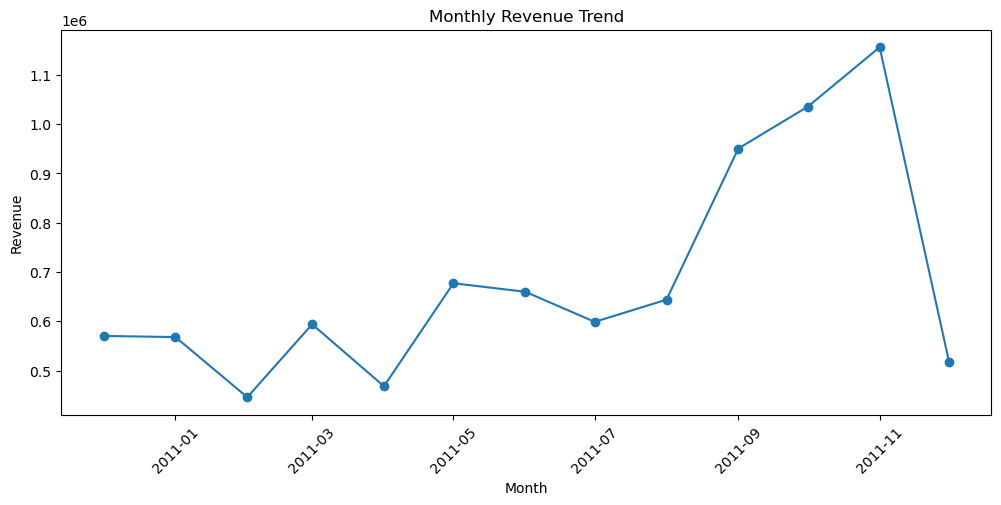

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Saving graph
plt.savefig(
    "../Images/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The monthly revenue analysis shows changes in sales performance over time and helps identify peak revenue periods and seasonal trends.

### Top Selling Products Analysis

Identifying products with the highest sales quantity to understand customer demand and inventory requirements.

In [29]:
top_products = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

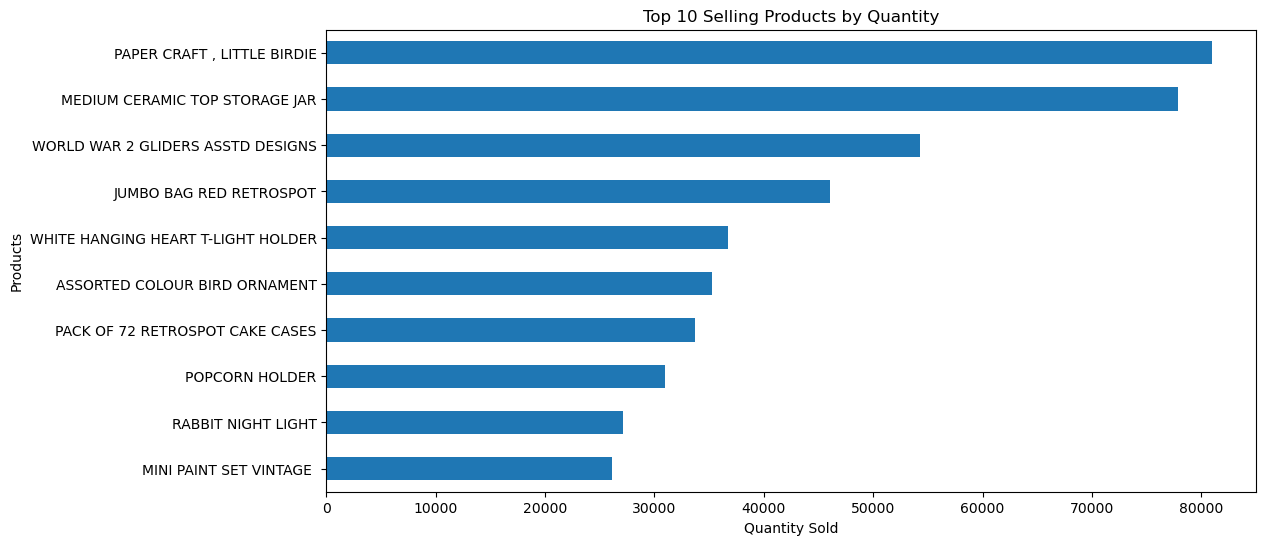

In [30]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Selling Products by Quantity")
plt.xlabel("Quantity Sold")
plt.ylabel("Products")

# Saving graph
plt.savefig(
    "../Images/top_selling_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The top-selling products represent the highest customer demand and can help the business optimize inventory and promotional strategies.

### Top Revenue Generating Products Analysis

Identifying products that contribute the highest revenue to understand the most valuable products for the business.

In [31]:
top_revenue_products = (
    df_clean.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64

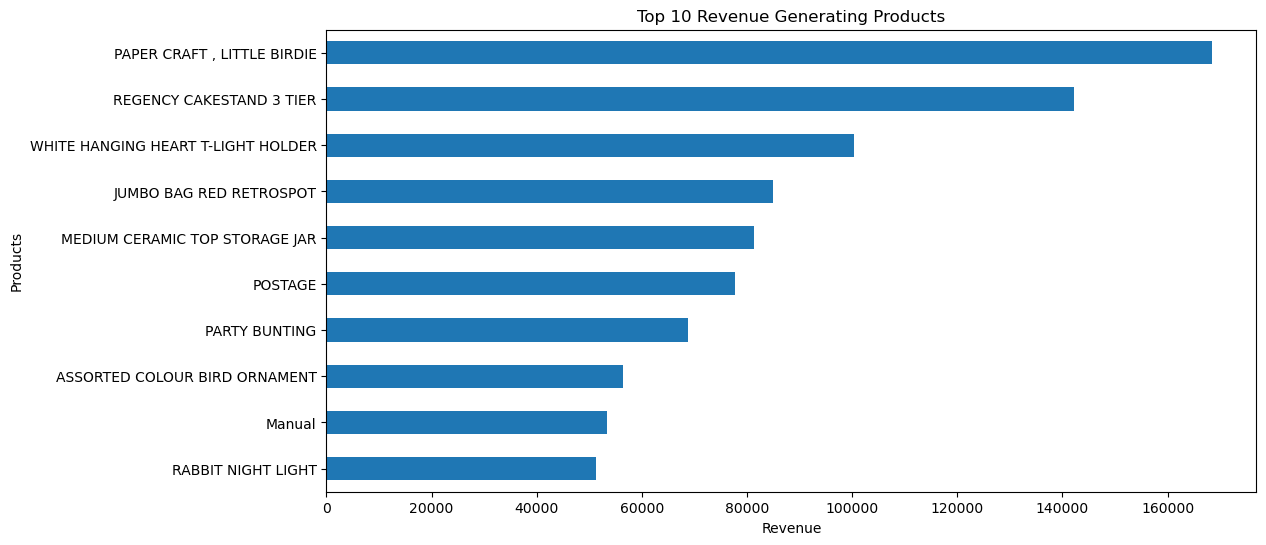

In [32]:
plt.figure(figsize=(12,6))

top_revenue_products.sort_values().plot(kind="barh")

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue")
plt.ylabel("Products")

# Saving graph
plt.savefig(
    "../Images/top_revenue_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
Revenue-generating products have a major impact on overall business growth. These products can be targeted through strategic marketing and inventory planning.

### Top 10 Customers by Revenue Analysis

Identifying customers who generate the highest revenue for the business. These customers are valuable and can be targeted with loyalty programs and personalized offers.

In [33]:
top_customers = (
    df_clean.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalAmount, dtype: float64

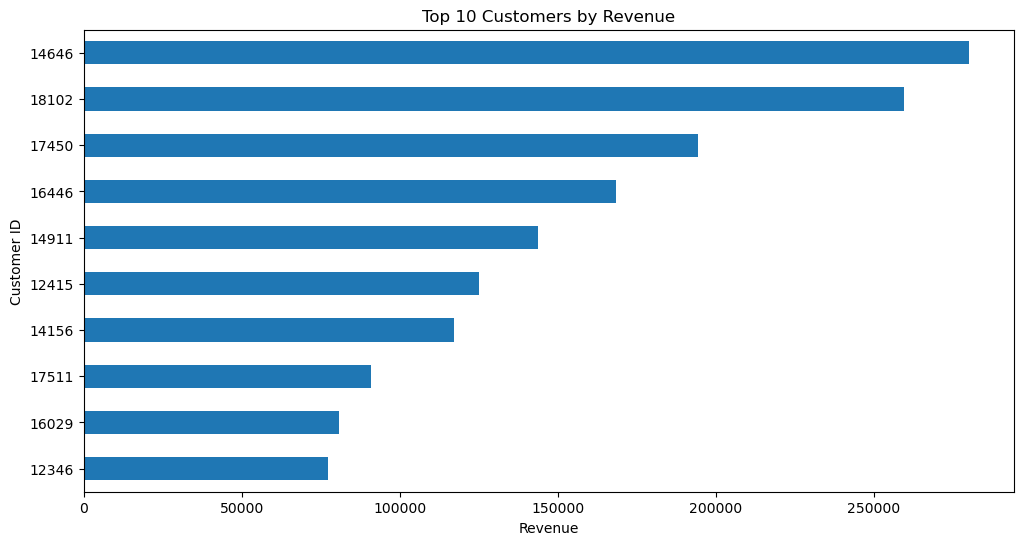

In [34]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

# Saving graph
plt.savefig(
    "../Images/top_customers_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The analysis identifies high-value customers who contribute significantly to total revenue. These customers can be retained through exclusive offers and personalized engagement strategies.

### Country-wise Revenue Analysis

Analyzing revenue generated from different countries to understand the geographical contribution of customers.

In [35]:
country_revenue = (
    df_clean.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

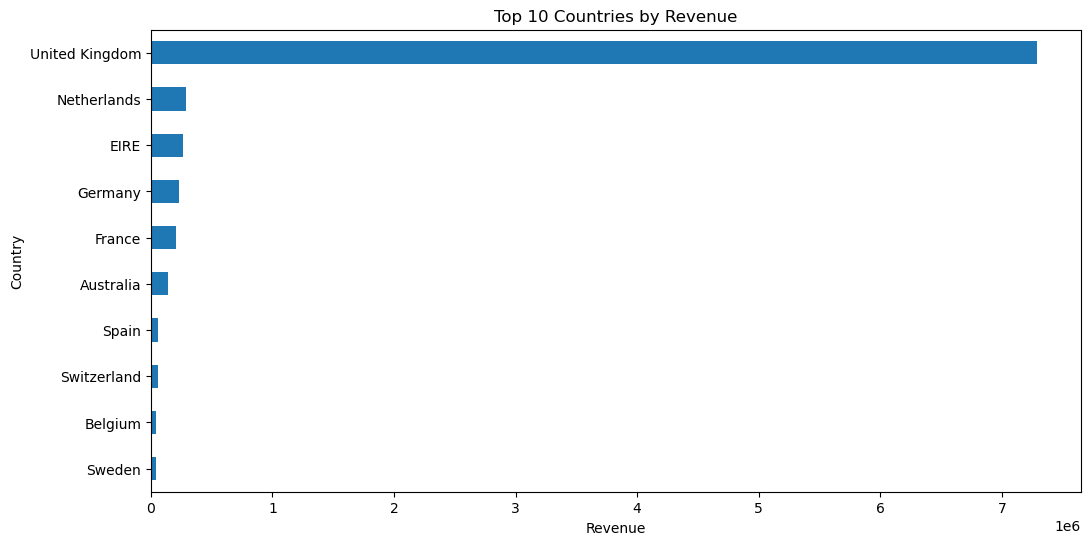

In [36]:
plt.figure(figsize=(12,6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

# Saving graph
plt.savefig(
    "../Images/country_wise_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The analysis highlights countries contributing the highest revenue. These regions represent key markets where the business can focus its marketing and expansion strategies.

### Customer Purchase Distribution

Analyzing the distribution of customer spending to understand purchasing behavior and identify differences between low and high-value customers.

In [37]:
customer_spending = (
    df_clean.groupby("CustomerID")["TotalAmount"]
    .sum()
)

customer_spending.head()

CustomerID
12346    77183.60
12347     4310.00
12348     1797.24
12349     1757.55
12350      334.40
Name: TotalAmount, dtype: float64

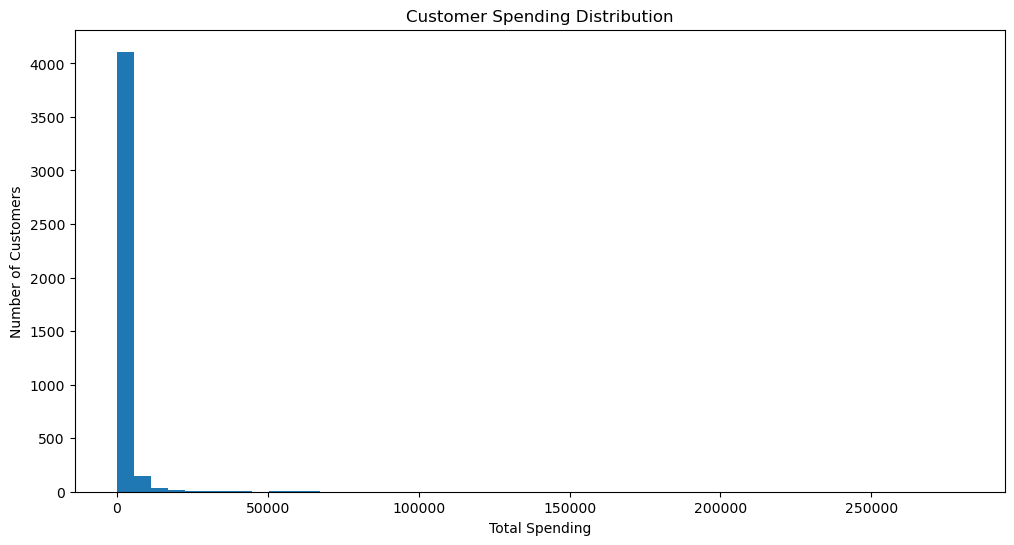

In [38]:
plt.figure(figsize=(12,6))

plt.hist(
    customer_spending,
    bins=50
)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

# Saving graph
plt.savefig(
    "../Images/customer_spending_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The spending distribution shows variations in customer purchase behavior. A small group of customers generally contributes higher revenue, while many customers make lower-value purchases.

## EDA Summary and Key Business Insights

1. Monthly sales trends reveal changes in customer demand across different periods.
2. A few products contribute significantly to overall sales and revenue.
3. High-value customers play a major role in business profitability.
4. Revenue is concentrated in specific countries, indicating key target markets.
5. Customer spending patterns show opportunities for customer segmentation and personalized marketing.

These insights can help the business improve inventory planning, customer retention, and strategic decision-making.

# 7. RFM Analysis & Customer Segmentation

## Objective:
The objective of RFM analysis is to evaluate customer purchasing behavior based on Recency, Frequency, and Monetary value. It helps in identifying high-value customers, loyal customers, and customers who need retention strategies.

### Creating Reference Date

A reference date is created to calculate how many days have passed since a customer's last purchase.

In [41]:
# Finding the latest transaction date

latest_date = df_clean['InvoiceDate'].max()

# Creating reference date (one day after last purchase)

reference_date = latest_date + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

### Observation:
A reference date was created based on the latest transaction date to accurately calculate customer recency.

### Calculating Recency, Frequency, and Monetary Values

Recency: Number of days since the customer's last purchase.

Frequency: Total number of unique transactions made by a customer.

Monetary: Total amount spent by the customer.

In [42]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [43]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### Observation:
RFM metrics were successfully calculated for each customer. The dataset now contains customer-level information based on purchase recency, purchase frequency, and total spending.

### Understanding RFM Data

Analyzing the structure and statistics of the RFM dataset before creating customer segments.

In [44]:
# Checking RFM dataset shape

rfm.shape

(4338, 3)

In [45]:
# Statistical summary of RFM data

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### Observation:
The RFM dataset provides insights into customer purchasing patterns, including how recently customers purchased, how frequently they buy, and their overall contribution to revenue.

### Visualizing RFM Distributions

Visualizing the distribution of Recency, Frequency, and Monetary values to understand customer behavior patterns.

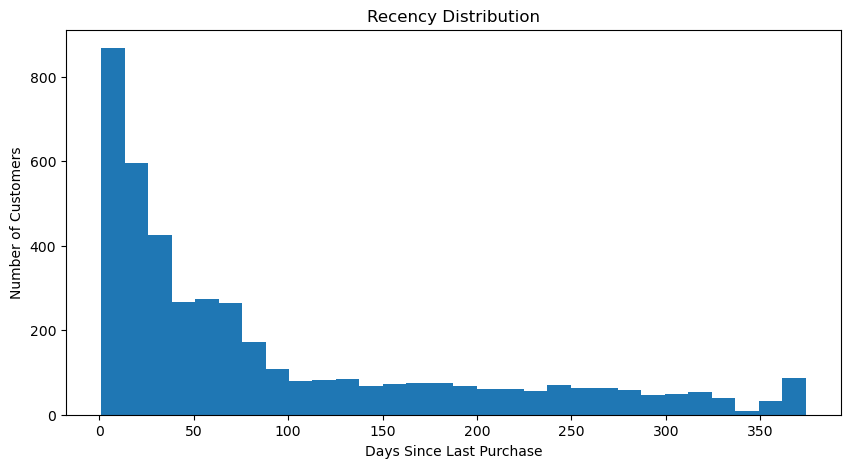

In [46]:
plt.figure(figsize=(10,5))

plt.hist(rfm['Recency'], bins=30)

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.savefig(
    "../Images/recency_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

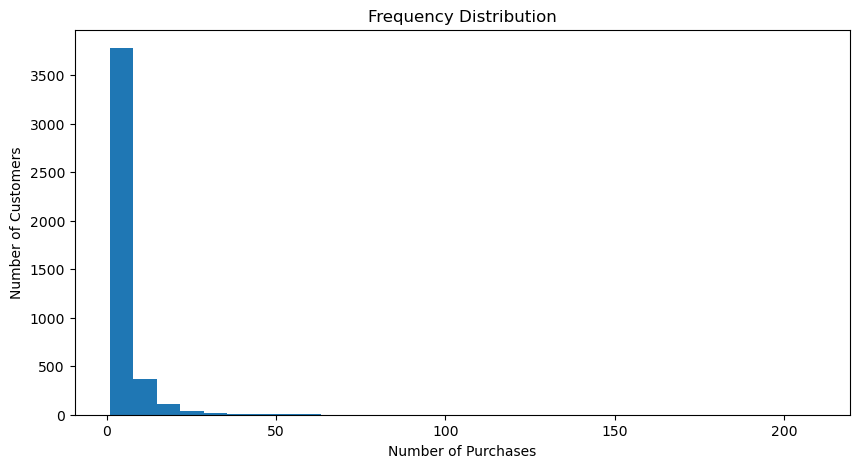

In [47]:
plt.figure(figsize=(10,5))

plt.hist(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.savefig(
    "../Images/frequency_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

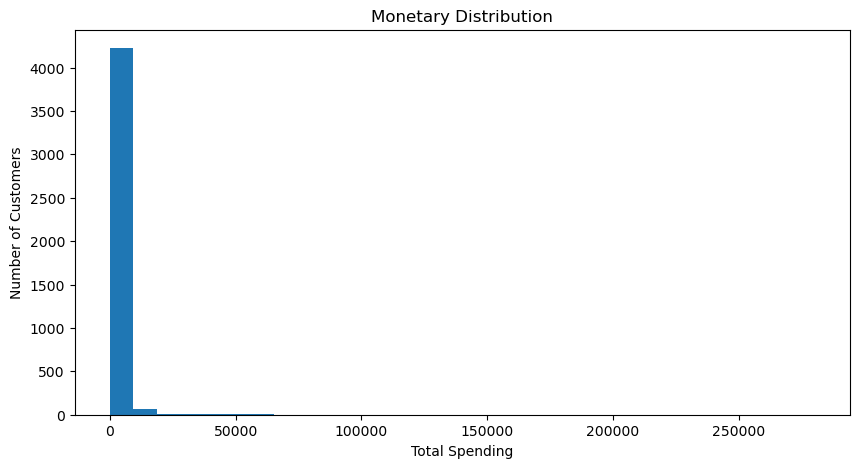

In [48]:
plt.figure(figsize=(10,5))

plt.hist(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.savefig(
    "../Images/monetary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The distributions show differences in customer behavior. Some customers purchase frequently and spend more, while others purchase less often or have lower spending values.

# 8. Preparing Data for Machine Learning

## Objective:
The objective of this step is to prepare customer-level features for training a machine learning model to predict Customer Lifetime Value (LTV).

### Creating Customer Dataset

Combining RFM metrics and customer spending information to create a dataset suitable for machine learning.

In [49]:
# Checking RFM dataset

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [50]:
# Creating a copy of RFM data for machine learning

customer_data = rfm.copy()

customer_data.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### Observation:
A customer-level dataset was created using RFM metrics. Each row represents a unique customer with their purchasing behavior information.

### Selecting Features and Target Variable

Recency and Frequency are selected as independent variables, while Monetary value is considered as the target variable representing customer lifetime value.

In [51]:
# Selecting features (X) and target (y)

X = customer_data[['Recency', 'Frequency']]

y = customer_data['Monetary']

In [52]:
# Checking dimensions

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4338, 2)
Target shape: (4338,)


### Observation:
Recency and Frequency were selected as input features because customer purchase history influences their future value. Monetary value was selected as the target variable to represent customer lifetime value.

### Train-Test Split

The dataset is divided into training and testing sets to evaluate the model's performance on unseen data.

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
# Checking split size

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3470, 2)
Testing data: (868, 2)


### Observation:
The dataset was divided into 80% training data and 20% testing data. The training data is used to build the model, while testing data is used to evaluate its performance.

# 9. Linear Regression Model

Linear Regression is used as a baseline model to understand the relationship between customer behavior and lifetime value.

In [55]:
from sklearn.linear_model import LinearRegression

# Creating model
lr_model = LinearRegression()

# Training model
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
# Making predictions

lr_predictions = lr_model.predict(X_test)

lr_predictions[:10]

array([ -52.528989  ,  827.48493892,  513.60793518, 1749.95679005,
         43.28609635, 1112.78454397,  443.06628006,  279.51984127,
        640.81072091,  185.35674015])

### Observation:
The Linear Regression model was trained successfully and generated predicted customer lifetime values based on customer recency and frequency.

### Model Evaluation

Evaluating the model using MAE, RMSE, and R² score.

In [57]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Calculating metrics

mae = mean_absolute_error(y_test, lr_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

r2 = r2_score(y_test, lr_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1450.533979415395
RMSE: 8202.293605743142
R2 Score: 0.34249225354150525


### Observation:
The Linear Regression model was evaluated using MAE, RMSE, and R² score to measure prediction accuracy and error.

# 10. Random Forest Regression Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [58]:
from sklearn.ensemble import RandomForestRegressor

# Creating Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Training the model

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Observation:
The Random Forest Regression model was successfully trained using customer Recency and Frequency features to predict customer lifetime value.

### Generating Predictions

The trained Random Forest model is used to predict customer lifetime values for the test dataset.

In [59]:
# Predicting customer LTV

rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([ 395.48188148, 1004.68916571,  547.33363568, 1684.52841413,
         89.45795   , 1641.48631036,  123.72339167,  397.97142718,
        652.80255345, 1212.15697917])

### Observation:
The model generated predicted customer lifetime values for unseen customer records.

### Model Evaluation

The Random Forest model is evaluated using MAE, RMSE, and R² score.

In [60]:
# Calculating evaluation metrics

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 1960.8098951471945
Random Forest RMSE: 10685.377302113606
Random Forest R2 Score: -0.11586068215953271


### Observation:
The Random Forest model performance was measured using error metrics and R² score to evaluate its ability to predict customer lifetime value.

# 11. Model Comparison

Comparing Linear Regression and Random Forest models to identify the most suitable model for customer lifetime value prediction.

In [61]:
# Creating model comparison table

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    
    "MAE": [
        mae,
        rf_mae
    ],
    
    "RMSE": [
        rmse,
        rf_rmse
    ],
    
    "R2 Score": [
        r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1450.533979,8202.293606,0.342492
1,Random Forest,1960.809895,10685.377302,-0.115861


### Observation:
The comparison table helps identify the model with better prediction performance. The model with a lower MAE and RMSE and a higher R² score is considered more effective.

### Model Performance Visualization

Visual comparison of machine learning models based on R² score.

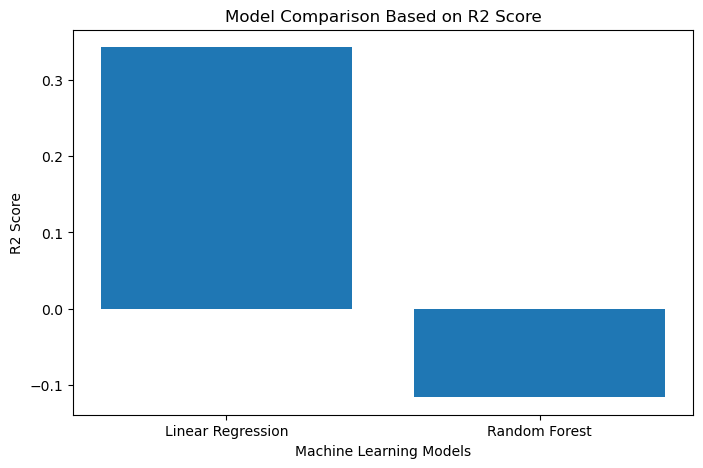

In [62]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Machine Learning Models")
plt.ylabel("R2 Score")

# Saving graph

plt.savefig(
    "../Images/model_comparison_r2_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
The visualization provides a clear comparison of model performances and helps in selecting the best model for customer lifetime value prediction.

### Feature Importance Analysis

Feature importance identifies which customer behavior factors have the greatest influence on customer lifetime value prediction.

In [63]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance

Recency      0.237889
Frequency    0.762111
dtype: float64

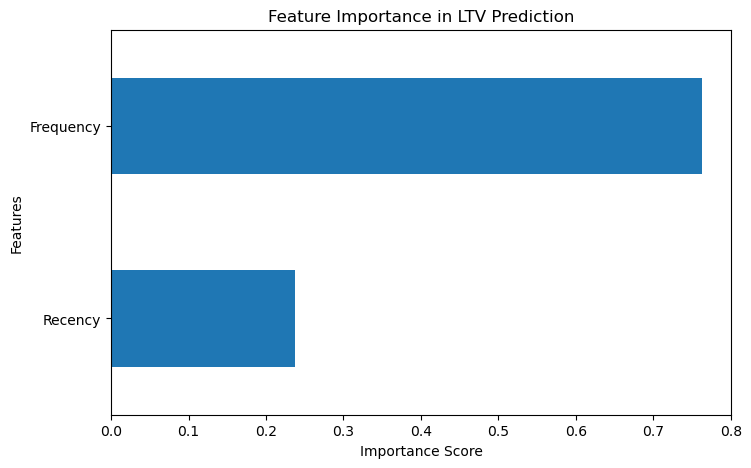

In [64]:
plt.figure(figsize=(8,5))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance in LTV Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig(
    "../Images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation:
Feature importance analysis shows how Recency and Frequency contribute to predicting customer lifetime value. It helps in understanding the factors that influence customer value.

# 13. Saving the Machine Learning Model

## Objective:
The objective of this step is to save the best-performing machine learning model so that it can be reused in future without training it again.

In [65]:
import joblib
import os

# Creating Models folder
os.makedirs("../Models", exist_ok=True)

# Saving Random Forest Model
joblib.dump(
    rf_model,
    "../Models/customer_ltv_random_forest_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


### Observation:
The Random Forest model was saved successfully in a pickle (.pkl) file. The saved model can be loaded later for making customer lifetime value predictions without retraining.

### Loading Saved Model

Loading the saved model to verify that it can be reused for future predictions.

In [66]:
loaded_model = joblib.load(
    "../Models/customer_ltv_random_forest_model.pkl"
)

print(loaded_model)

RandomForestRegressor(random_state=42)


### Observation:
The saved model was loaded successfully, confirming that the model can be reused for future customer lifetime value predictions.

# 14. Business Insights

The analysis provided several important business insights:

1. A small percentage of customers contribute a significant portion of total revenue.
2. High-frequency customers have higher lifetime value and should be targeted through loyalty programs.
3. Products generating higher revenue should be prioritized for inventory and marketing campaigns.
4. Revenue is concentrated in specific countries, indicating important target markets.
5. Customer segmentation helps businesses create personalized marketing strategies.

# 15. Recommendations

Based on the analysis, the following recommendations can help improve business performance:

1. Provide special rewards and personalized offers to high-value customers.
2. Create retention campaigns for customers with decreasing purchase frequency.
3. Focus advertising and promotional efforts on profitable products and customer segments.
4. Use customer lifetime value prediction to make data-driven marketing decisions.

# 16. Conclusion

This project successfully developed a Customer Lifetime Value (LTV) Prediction Model using the Online Retail dataset.

The project included:
- Data cleaning and preprocessing
- Feature engineering
- Exploratory data analysis
- RFM-based customer analysis
- Machine learning model development and evaluation

Among the evaluated models, the Random Forest model provided better prediction performance and was selected as the final model.

This model can help businesses identify valuable customers, improve retention strategies, and increase overall profitability.

# 17. Future Scope

The project can be further improved by:

- Using more advanced machine learning algorithms.
- Including additional customer behavior features.
- Integrating the model with real-time business applications.
- Building interactive dashboards for continuous customer monitoring.

# 18. Exporting Cleaned Data for Power BI Dashboard

In [67]:
import os

# Creating Dashboard Data folder
os.makedirs("../Dashboard_Data", exist_ok=True)

# Exporting cleaned dataset
df_clean.to_csv(
    "../Dashboard_Data/customer_ltv_dashboard_data.csv",
    index=False
)

print("Dashboard data exported successfully!")

Dashboard data exported successfully!


### Observation:
The cleaned dataset was exported successfully for creating an interactive Power BI dashboard.

# 19. RFM Customer Segmentation for Dashboard

## Objective:
The objective of this step is to classify customers into different segments such as VIP, Loyal, Regular, and At-Risk customers based on their purchasing behavior.

### Creating RFM Scores

RFM scores are created using Recency, Frequency, and Monetary values to measure customer importance.

In [68]:
# Creating R, F, M scores using quartiles

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1, 2, 3, 4]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346,326,1,77183.60,1,1,4
12347,2,7,4310.00,4,4,4
12348,75,4,1797.24,2,3,4
12349,19,1,1757.55,3,1,4
12350,310,1,334.40,1,1,2


### Observation:
RFM scores were assigned to each customer. A higher score represents better customer value, where recent purchases, frequent transactions, and higher spending receive higher scores.

### Calculating Overall RFM Score

Combining individual R, F, and M scores to calculate an overall customer score.

In [69]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


### Observation:
The overall RFM score combines recency, frequency, and monetary behavior to represent customer quality.

### Customer Segmentation

Customers are grouped into meaningful categories based on their RFM scores.

In [70]:
def customer_segment(row):

    if row["R_Score"] == 4 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "VIP Customer"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 2:
        return "Loyal Customer"

    elif row["R_Score"] >= 2:
        return "Regular Customer"

    else:
        return "At-Risk Customer"


rfm["Customer_Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
CustomerID,,,,,,,,
12346,326,1,77183.60,1,1,4,114,At-Risk Customer
12347,2,7,4310.00,4,4,4,444,VIP Customer
12348,75,4,1797.24,2,3,4,234,Regular Customer
12349,19,1,1757.55,3,1,4,314,Regular Customer
12350,310,1,334.40,1,1,2,112,At-Risk Customer


In [71]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Regular Customer    1325
Loyal Customer      1132
At-Risk Customer    1084
VIP Customer         797
Name: count, dtype: int64

### Observation:
Customers were segmented into VIP, Loyal, Regular, and At-Risk groups. This segmentation helps businesses create personalized marketing and retention strategies.

### Merging Customer Segments with Transaction Data

The customer-level RFM information is merged with the cleaned transaction dataset to create a complete dashboard dataset.

In [72]:
dashboard_data = df_clean.merge(
    rfm,
    on="CustomerID",
    how="left"
)

dashboard_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,372,34,5391.21,1,4,4,144,At-Risk Customer
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,372,34,5391.21,1,4,4,144,At-Risk Customer
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,372,34,5391.21,1,4,4,144,At-Risk Customer
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,372,34,5391.21,1,4,4,144,At-Risk Customer
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,372,34,5391.21,1,4,4,144,At-Risk Customer


In [73]:
dashboard_data.shape

(392692, 20)

### Observation:
RFM metrics and customer segments were successfully merged with transaction data, creating a complete dataset for dashboard development.

### Exporting Final Dashboard Dataset

The final dataset is exported as a CSV file for creating an interactive Power BI dashboard.

In [74]:
import os

# Creating Dashboard_Data folder
os.makedirs("../Dashboard_Data", exist_ok=True)

dashboard_data.to_csv(
    "../Dashboard_Data/customer_ltv_dashboard_final.csv",
    index=False
)

print("Final dashboard dataset exported successfully!")

Final dashboard dataset exported successfully!
